# Covalently attach fragments to a mutated protein

### Joseph R. Laforet Jr.

Notebook 03 turned wild-type fibronectin FN7–10 into the labeling construct,
p-azido-L-phenylalanine (AzF) at 1381 and cysteine at 1500. This notebook puts
the FRET dye molecules on it. 

The FRET donor carries a strained alkyne (a DBCO group) and goes
onto the azide by a copper-free click reaction, which closes a triazole ring. The
FRET acceptor carries a maleimide and goes onto the cysteine thiol by a Michael
addition, which moves the thiol hydrogen onto the ring.

Neither reaction is "replace one hydrogen with one bond", so neither can be
written with `attach`'s leaving-atom keywords. Both are written as a **reaction
string**, an RDKit reaction SMARTS that `attach` reads as a rule. 

The last part
of the notebook describes how to construct `ResidueDefinition`s for the two
new residues for OpenFF Pablo using Pablo's own public API. We use the atoms and
bonds mBuild holds, so that the written PDB file loads as a complete chemical
graph.

This notebook teaches three things about the module:

- A **reaction string** is an RDKit reaction SMARTS that `attach` reads as a
  rule: which atoms leave, which bonds form or change, which charges change.
  `REACTIONS` ships a few. You can write your own.
- A product joined to the protein by two bonds must be **one residue** for a
  downstream library. That is what `merge=True` does.
- A residue definition for a downstream library is **read off the mBuild
  `Residue`**, which already holds every atom, bond, order and charge.

In the review stack this is the second half of PR 5.

Everything below uses the public API of mBuild, RDKit, the OpenFF Toolkit and
Pablo. 

NOTE: If you have suggestions for how to improve this functionality/feature, please file an issue!

In [22]:
import logging
import time
import warnings

warnings.filterwarnings("ignore", message="pkg_resources is deprecated")

from rdkit import Chem
from rdkit.Chem import Draw

from mbuild.biopolymers import REACTIONS, Protein, prepare_fragment
from demo_utils import show_protein

logging.getLogger("mbuild").setLevel(logging.WARNING)

protein = Protein("1fnf_S1381AzF_S1500C.pdb", download=True)
azf, cys = protein.get_residue(1381, chain_id="A"), protein.get_residue(1500, chain_id="A")
print(f"{protein.n_particles} atoms, net formal charge {protein.net_formal_charge}")
print(f"{azf.name} {azf.resnum}: charges {azf.atom_formal_charges}   |   {cys.name} {cys.resnum}: {sorted(p.name for p in cys.particles())}")

5595 atoms, net formal charge -6
4II 1381: charges {'N2': 1, 'N3': -1}   |   CYS 1500: ['C', 'CA', 'CB', 'H', 'HA', 'HB2', 'HB3', 'HG', 'N', 'O', 'SG']


## The two FRET probes

Both SMILES come from a paper we are working to model, with two edits made here. The acceptor as
published is the NHS-ester form, which reacts with amines; the paper used the
**maleimide-activated** form on the cysteine, so the NHS ester is replaced by an
amide to N-(2-aminoethyl)maleimide. And both dyes were drawn with three of their
four sulfonates as acids; at pH 7 all four are anions, so they are written
deprotonated and each dye carries a charge of −3. 

The formal charges in a SMILES
are what mBuild stores and what the force field will see, so this is where the
protonation state is decided.

`prepare_fragment` turns each SMILES into a `Residue` with unique atom names and
the formal charges. No `*` is needed, so `link_atoms` stays empty: with a reaction string, the
reaction template picks the atoms on both sides.

DON: 129 atoms, formal charge -3
ACC: 111 atoms, formal charge -3


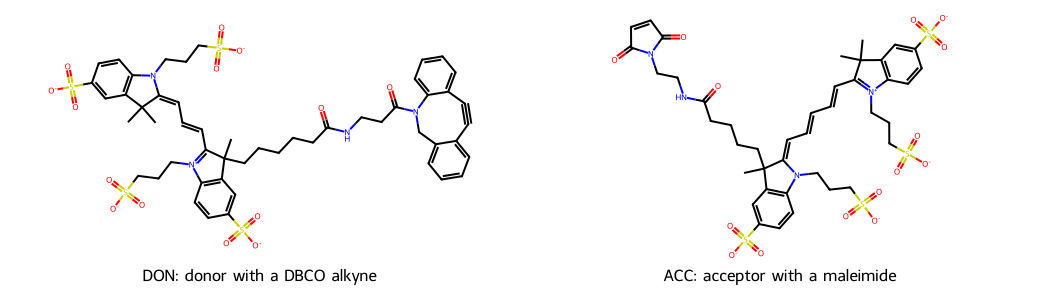

In [23]:
DONOR = ("CC1(CCCCCC(=O)NCCC(=O)N2Cc3ccccc3C#Cc3ccccc32)C(/C=C/C=C2/N(CCCS(=O)(=O)[O-])"
         "c3ccc(S(=O)(=O)[O-])cc3C2(C)C)=[N+](CCCS(=O)(=O)[O-])c2ccc(S(=O)(=O)[O-])cc21")
ACCEPTOR = ("CC1(C)C(/C=C/C=C/C=C2\\N(CCCS(=O)(=O)[O-])c3ccc(S(=O)(=O)[O-])cc3C2(C)CCCCC(=O)NCCN2C(=O)C=CC2=O)"
            "=[N+](CCCS(=O)(=O)[O-])c2ccc(S(=O)(=O)[O-])cc21")

donor = prepare_fragment(DONOR, "DON")
acceptor = prepare_fragment(ACCEPTOR, "ACC")
for dye in (donor, acceptor):
    print(f"{dye.name}: {dye.n_particles} atoms, formal charge {dye.formal_charge}")
Draw.MolsToGridImage([Chem.MolFromSmiles(DONOR), Chem.MolFromSmiles(ACCEPTOR)], molsPerRow=2,
                     subImgSize=(520, 300), legends=["DON: donor with a DBCO alkyne", "ACC: acceptor with a maleimide"])

## The reaction strings

`mbuild.biopolymers.REACTIONS` is a dict of reaction SMARTS strings, keyed by
name. 

`attach` accepts either the name or the SMARTS itself. Every string has
two reactant templates, the protein side first, and one product template.
Unmapped atoms leave, bonds present only in the product form, and the product
sets the bond orders and formal charges.

NOTE: We can add more reactions as users contribute things they are interested in modeling. Click chemistry is a fairly common reaction.

In [24]:
for name, smarts in REACTIONS.items():
    print(f"{name:24s} {smarts}")

hydrogen substitution    [*:1][H].[*:2][H]>>[*:1][*:2]
amide coupling           [N:1]([H:2])[H].[C:3](=[O:4])[O][H]>>[N:1]([H:2])[C:3]=[O:4]
thiol-maleimide          [S:1][H:2].[O:5]=[C:6]1[N:7][C:8](=[O:9])[C:3]=[C:4]1>>[S:1][C:3]1[C:8](=[O:9])[N:7][C:6](=[O:5])[C:4]1[H:2]
azide-alkyne triazole    [N:1]=[N+:2]=[N-:3].[C:4]#[C:5]>>[N:1]1[N+0:2]=[N+0:3][C:4]=[C:5]1
N-glycosylation          [N:1]([H:2])[H].[C:3][O][H]>>[N:1]([H:2])[C:3]
O-glycosylation          [O:1][H].[C:2][O][H]>>[O:1][C:2]


hydrogen substitution    [*:1][H].[*:2][H]>>[*:1][*:2]


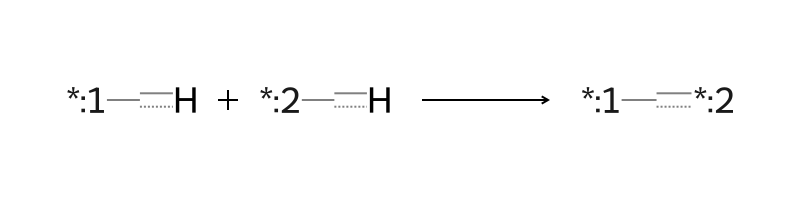

amide coupling           [N:1]([H:2])[H].[C:3](=[O:4])[O][H]>>[N:1]([H:2])[C:3]=[O:4]


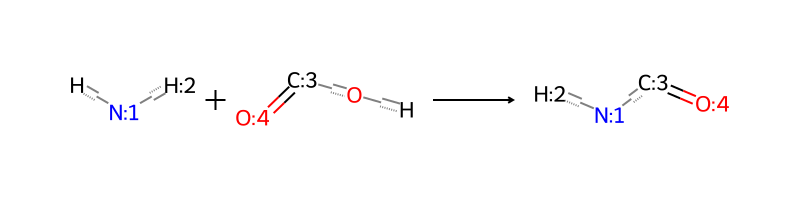

thiol-maleimide          [S:1][H:2].[O:5]=[C:6]1[N:7][C:8](=[O:9])[C:3]=[C:4]1>>[S:1][C:3]1[C:8](=[O:9])[N:7][C:6](=[O:5])[C:4]1[H:2]


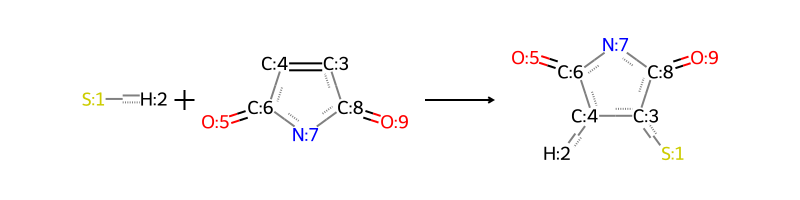

azide-alkyne triazole    [N:1]=[N+:2]=[N-:3].[C:4]#[C:5]>>[N:1]1[N+0:2]=[N+0:3][C:4]=[C:5]1


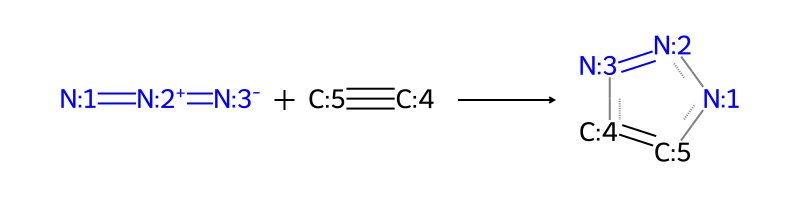

N-glycosylation          [N:1]([H:2])[H].[C:3][O][H]>>[N:1]([H:2])[C:3]


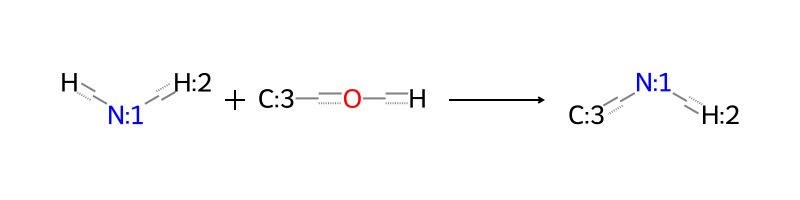

O-glycosylation          [O:1][H].[C:2][O][H]>>[O:1][C:2]


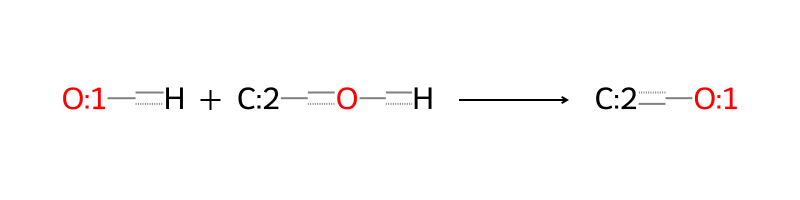

In [27]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdChemReactions as Reactions

# Define your reaction SMARTS string
for name in REACTIONS.keys():
    print(f"{name:24s} {REACTIONS[name]}")
    rxn = Reactions.ReactionFromSmarts(REACTIONS[name])
    img = Draw.ReactionToImage(rxn)
    display(img)


### Remember, the first (leftmost) reactant in the image is the moiety on the PROTEIN.

How `attach` reads one, on the thiol-maleimide string:

1. Each reactant template is matched on its side, hydrogens included. The
   protein template must contain the atom named in the call, which keeps the
   match local on a protein with many thiols.
2. A mapped atom [atom with numbers] (`:n`) is kept. An unmapped atom leaves, together with
   everything beyond it away from the mapped atoms. This is the leaving-atom
   rule from notebook 2, written into the template.
3. A bond between mapped atoms that is in the product and not in the
   reactants is formed, with the product's order. Here `S:1`–`C:3` and
   `C:4`–`H:2`: the thiol hydrogen changes partners and moves into the dye.
4. A bond whose order differs takes the product's order: `C:3`=`C:4` becomes
   single.
5. A charge written in the product is applied. The triazole string writes
   `[N+0:2]` and `[N+0:3]`, so the azide charges vanish.
6. Only a hydrogen can be created. A heavy atom the reactants do not supply is
   refused, because nothing gives it coordinates.

To write your own, start from the shipped string closest to your reaction
and put the protein side first. Put enough of the surroundings in the
template to make the match unique: the whole maleimide ring is in this one,
so a dye's other double bonds cannot match by accident.

## Click the FRET donor onto AzF

The triazole joins the two sides by **two** bonds, so this reaction is a ring
closure. `attach` places the dye by fitting it to both bonds at once and then
relaxes it with the protein held fixed until both are at bond length.

OpenFF Pablo describes a
bond between residues as a *crosslink*, and it currently allows one crosslink per residue.
Two bonds between the same two residues cannot be declared. Any product that a ring closure
joins to the protein is therefore written as **one residue**: `merge=True` moves the dye's atoms into
residue 1381, which keeps its number, takes the dye's charges, and drops its CCD
template because no CCD component describes it. It is then renamed, since the
name `4II` would tell a library to expect the azide.

The print below shows what that does to the `Residue`: `template` is `None`,
because no CCD component describes the product, and the azide charges are gone
from `atom_formal_charges`, because the product template says so.

NOTE: May be something to discuss with Pablo devs, multiple crosslink bonds would allow us to treat "ring formation" as a single residue, rather than forcing the modified protein residue + the dye to be one residue. This is just labeling though.

In [28]:
start = time.time()
labeled = protein.attach(donor, resnum=1381, atom_name="N3", chain_id="A",
                         reaction="azide-alkyne triazole", merge=True)
labeled.name = "TZ1"
print(f"{time.time() - start:.0f} s")
print(f"{labeled.name} {labeled.resnum}: {labeled.n_particles} atoms, formal charge {labeled.formal_charge}, "
      f"template {labeled.template}, azide charges left: {[n for n in ('N2', 'N3') if n in labeled.atom_formal_charges] or 'none'}")
print("residues:", len(list(protein.residues())), "| bonds recorded by this step:", len([b for b in protein.cross_bonds if b.reaction]))

83 s
TZ1 1381: 151 atoms, formal charge -3, template None, azide charges left: none
residues: 368 | bonds recorded by this step: 0


## Add the FRET acceptor to the cysteine

The thiol adds across the maleimide double bond. The sulfur bonds one carbon,
the thiol hydrogen ends up on the other, and the double bond becomes a single bond.

Only one bond joins the two sides, so the dye stays its own residue and the bond
is recorded as an `InterResidueBond`, the same object notebook 2 returned, now
with its `reaction` field set: `bond_records()` names the residues, the atoms, the hydrogen that
left the cysteine (it moved to the dye, but from the file's point of view it is
gone from the cysteine) and the reaction. That record is what a residue library
needs.

In [29]:
start = time.time()
record = protein.attach(acceptor, resnum=1500, atom_name="SG", chain_id="A", reaction="thiol-maleimide")
print(f"{time.time() - start:.0f} s")
bond = [r for r in protein.bond_records() if "reaction" in r][0]
print({k: v for k, v in bond.items() if k != "reaction"})
print(f"net formal charge of the labeled protein: {protein.net_formal_charge}   (−6 from the protein, −3 per dye)")

2026-09-21 14:56:56,395 - mbuild.biopolymers.protein - WARNING - 78 placed atoms sit within 2.0 A of existing atoms (closest: 0.37 A). Relax the structure before simulating (e.g. relax_fragments(), which holds the protein fixed).


2026-09-21 14:59:09,263 - mbuild.biopolymers.protein - WARNING - Relaxation left a fragment atom 1.08 A from an existing atom. Inspect the site; the minimizer may not have converged.


133 s
{'residue_names': ('CYS', 'ACC'), 'residue_numbers': (1500, 1510), 'chain_ids': ('A', 'A'), 'icodes': ('', ''), 'atom_names': ('SG', 'C31'), 'leaving_atoms': (['HG'], []), 'bond_order': 1}
net formal charge of the labeled protein: -12   (−6 from the protein, −3 per dye)


In [30]:
show_protein(protein, link_selection="1381:A or 1500:A", fragment_selection="[TZ1] or [ACC]")

NGLWidget(layout=Layout(height='500px', width='700px'))

## Write the mutated, FRET-probe modified protein

We need to construct a custom residue definition for the modified cysteine so Pablo can load it, since Pablo's cysteine definition already carries a crosslink.
This is the same renaming any force field asks for when it has its own name for a
modified residue.

In [31]:
record.residue1.name = "CYL"
record.residue1.hetatm = True
protein.save_pdb("1fnf_labeled.pdb", overwrite=True)

## Describe any mBuild residue to a downstream library

Pablo reads a PDB file by matching every residue to a *residue definition*: the
free molecule with its atom names, elements, bonds, bond orders and formal
charges, plus the atoms that leave when the residue bonds to a neighbour. The
CCD supplies those for the standard residues. For `TZ1`, `CYL` and `ACC` we
build them ourselves, and the source is the mBuild `Residue`, which holds exactly
that information: `particles()` with elements and names,
`bonds(return_bond_order=True)`, and `atom_formal_charges`.

Nothing in the function below is specific to these three residues. It works for
the TFB side chain of notebook 3, for a glycan residue read from a PDB file, or
for any residue `attach` or `mutate` made.

The function below does the following:

1. Copy the residue's atoms, bonds, bond orders and formal charges into an RDKit
   molecule.
2. A residue in the chain is described as the free amino acid, so add the atoms a
   peptide bond removes: a second hydrogen on `N`, and `OXT` with its `HXT` on
   `C`. Mark them as leaving atoms, and declare Pablo's `PEPTIDE_BOND`.
3. An atom that bonds another residue by a crosslink gets a hydrogen that
   completes its valence in the free molecule. It is a bookkeeping atom, not a
   reaction intermediate: Pablo's own cysteine describes the disulfide the same
   way, through `HG`. `with_crosslink` below marks it as the atom that leaves.
4. Convert to an OpenFF `Molecule`, transfer the atom names, and call
   `ResidueDefinition.from_molecule`.

In [32]:
from openff.pablo import STD_CCD_CACHE, ResidueDefinition, topology_from_pdb
from openff.pablo.chem import PEPTIDE_BOND
from openff.toolkit import Molecule

BOND_TYPES = {1.0: Chem.BondType.SINGLE, 2.0: Chem.BondType.DOUBLE, 3.0: Chem.BondType.TRIPLE, 1.5: Chem.BondType.AROMATIC}


def definition_from_residue(residue, name, in_chain, crosslink_atoms=()):
    '''Build a Pablo ResidueDefinition from an mBuild Residue.

    in_chain adds the peptide leaving atoms and declares the peptide bond.
    crosslink_atoms are atoms bonded to another residue; each gets a
    hydrogen that with_crosslink() will mark as leaving. Returns the
    definition and the names of those hydrogens.
    '''
    editable, index, names = Chem.RWMol(), {}, []
    for particle in residue.particles():
        atom = Chem.Atom(particle.element.symbol)
        atom.SetFormalCharge(residue.atom_formal_charges.get(particle.name, 0))
        atom.SetNoImplicit(True)
        index[particle] = editable.AddAtom(atom)
        names.append((particle.name, False))
    for p1, p2, data in residue.bonds(return_bond_order=True):
        editable.AddBond(index[p1], index[p2], BOND_TYPES[float(data["bond_order"])])

    taken = {n for n, _ in names}

    def fresh(name):
        while name in taken:
            name += "X"
        taken.add(name)
        return name

    def add(symbol, to, name, leaving):
        atom = Chem.Atom(symbol)
        atom.SetNoImplicit(True)
        new = editable.AddAtom(atom)
        editable.AddBond(to, new, Chem.BondType.SINGLE)
        names.append((fresh(name), leaving))
        return new

    if in_chain:
        add("H", index[next(residue.particles_by_name("N"))], "H2", leaving=True)
        oxt = add("O", index[next(residue.particles_by_name("C"))], "OXT", leaving=True)
        add("H", oxt, "HXT", leaving=True)
    caps = []
    for atom_name in crosslink_atoms:
        add("H", index[next(residue.particles_by_name(atom_name))], "H" + atom_name[1:], leaving=False)
        caps.append(names[-1][0])

    mol = editable.GetMol()
    Chem.SanitizeMol(mol)
    molecule = Molecule.from_rdkit(mol, allow_undefined_stereo=True)
    for atom, (atom_name, leaving) in zip(molecule.atoms, names):
        atom.name = atom_name
        atom.metadata["leaving_atom"] = leaving
    definition = ResidueDefinition.from_molecule(
        molecule, residue_name=name, linking_bond=PEPTIDE_BOND if in_chain else None
    )
    return definition, caps

The click product `TZ1` is part of the protein chain and has no crosslink, since we merged the dye and protein residue into one. The labeled
cysteine `CYL` is part of the protein chain and crosslinks through `SG`; the dye `ACC`
is a free residue that crosslinks through the carbon the bond record names.

The crosslink declaration is then read straight from the record: the two
residues, the two atoms, and the atoms that are absent from the file because
the bond exists. 

This is `HG` for cysteine, as the record says, and the bookkeeping hydrogen for the dye.

In [33]:
tz1, _ = definition_from_residue(labeled, "TZ1", in_chain=True)
cyl, cyl_caps = definition_from_residue(record.residue1, "CYL", in_chain=True, crosslink_atoms=[bond["atom_names"][0]])
acc, acc_caps = definition_from_residue(record.residue2, "ACC", in_chain=False, crosslink_atoms=[bond["atom_names"][1]])
for d in (tz1, cyl, acc):
    print(f"{d.residue_name}: {len(d.atoms)} atoms, {sum(a.leaving for a in d.atoms)} leaving, "
          f"charge {sum(a.charge for a in d.atoms)}, linking bond {'yes' if d.linking_bond else 'no'}")

assert bond["leaving_atoms"][0] == cyl_caps, (bond["leaving_atoms"][0], cyl_caps)
library = STD_CCD_CACHE.with_({"TZ1": [tz1], "CYL": [cyl], "ACC": [acc]})
library = library.with_crosslink(
    residues=("CYL", "ACC"),
    linking_atoms=tuple(bond["atom_names"]),
    leaving_atoms=(cyl_caps, acc_caps),
    bond_order=bond["bond_order"],
)

TZ1: 154 atoms, 3 leaving, charge -3, linking bond yes
CYL: 14 atoms, 3 leaving, charge 0, linking bond yes
ACC: 113 atoms, 0 leaving, charge -3, linking bond no


## Load the file with Pablo

If Pablo can explain every atom and every bond from the definitions, it returns
an OpenFF `Topology`. Anything it cannot explain is an error naming the residue,
so a success here means the chemistry mBuild built survived the trip through
the file.

In [34]:
topology = topology_from_pdb("1fnf_labeled.pdb", residue_library=library)
print(f"Pablo: {topology.n_atoms} atoms, {topology.n_molecules} molecule, {topology.n_bonds} bonds, "
      f"net charge {sum(a.formal_charge.m for a in topology.atoms)}")
print(f"mBuild: {protein.n_particles} atoms, {protein.n_bonds} bonds, net charge {protein.net_formal_charge}")
for name in ("TZ1", "CYL", "ACC"):
    atoms = [a for a in topology.molecule(0).atoms if a.metadata["residue_name"] == name]
    print(f"   {name}: {len(atoms)} atoms in the topology")

Pablo: 5835 atoms, 1 molecule, 5920 bonds, net charge -12
mBuild: 5835 atoms, 5920 bonds, net charge -12
   TZ1: 151 atoms in the topology
   CYL: 10 atoms in the topology
   ACC: 112 atoms in the topology


## Assigning force field parameters, solvating in water, and a short simulation with OpenMM

Everything from here on is downstream of mBuild; the topology is done. From
here the workflow is the same as notebook 02's, with two sites instead of one. The
standard residues keep their ff14SB library charges. Each labeled site,
`TZ1` alone (its dye is inside the residue) and `CYL` with `ACC`, gets NAGL
graph charges on a capped local model (the residue and fragment plus every
atom within two bonds) with a hydrogen closing each cut bond.

`parameterize_with_preset_charges` then assigns ff14SB to every term inside
the unmodified protein and Sage to every term that touches a modification site, with the
split charges passed in as presets.

Water is optional. A solvated box of this 5,800-atom protein plus two dyes
holds tens of thousands of atoms and a short run takes minutes on a CPU; in
vacuum the same run takes seconds and still shows the dyes moving. Set
`SOLVATE = True` for the real thing.

In [35]:
import demo_charges

SOLVATE = True          # True: pack water around the protein before the run (slower)
N_FRAMES, STEPS_PER_FRAME = 40, 250      # 40 frames x 0.5 ps = 20 ps of dynamics

sites = [
    dict(fragment_resname=None, resnum=1381, chain_id="A"),     # TZ1: the dye is inside the residue
    dict(fragment_resname="ACC", resnum=1500, chain_id="A"),    # CYL with its dye
]
# The ff14SB reference is the wild type. Pablo cannot read the viewer's
# hydrogen names in 1fnf_clean.pdb, so mBuild writes the file it reads.
Protein("1fnf_clean.pdb").save_pdb("1fnf_prepared.pdb", overwrite=True)
unmodified_topology = topology_from_pdb("1fnf_prepared.pdb")
conjugate = demo_charges.assign_split_charges(topology.molecule(0), unmodified_topology, sites=sites)

charges of TZ11381
 residue   atom    ff14SB      NAGL     final     delta
 TZ11381      N   -0.4157   -0.5663   -0.5663   -0.1506
 TZ11381     CA   -0.0249   +0.0357   +0.0357   +0.0606
 TZ11381      C   +0.5973   +0.6393   +0.6393   +0.0420
 TZ11381      O   -0.5679   -0.6079   -0.6079   -0.0400
 TZ11381     HA   +0.0843   +0.0892   +0.0892   +0.0049
 TZ11381      H   +0.2719   +0.3083   +0.3083   +0.0364
 TZ11381     N1         -   +0.1148   +0.1148         -
 TZ11381     N2         -   -0.1535   -0.1535         -
 TZ11381     N3         -   -0.3300   -0.3300         -
 TZ11381     CB   +0.2117   -0.0532   -0.0532   -0.2649
 TZ11381     CG         -   -0.0795   -0.0795         -
 TZ11381    CD2         -   -0.1175   -0.1175         -
 TZ11381    CE2         -   -0.1044   -0.1044         -
 TZ11381     CZ         -   +0.0075   +0.0075         -
 TZ11381    CE1         -   -0.1044   -0.1044         -
 TZ11381    CD1         -   -0.1175   -0.1175         -
 TZ11381     H6         -   +

The unmodified topology is the wild type, written by mBuild with CCD atom
names so Pablo reads it, so the ff14SB reference has an atom for every
standard-residue atom of the labeled protein; only the atoms of the two sites
are missing from it, and those take the graph charges.

In [36]:
from openff.toolkit import Topology

if SOLVATE:
    from openff.interchange.components._packmol import UNIT_CUBE, pack_box
    from openff.units import unit as off_unit

    water = Molecule.from_smiles("O")
    water.generate_conformers(n_conformers=1)
    for atom in water.atoms:
        atom.metadata["residue_name"] = "HOH"
    system_topology = pack_box([water], [12000], solute=Topology.from_molecules([conjugate]),
                               target_density=0.95 * off_unit.gram / off_unit.milliliter,
                               box_shape=UNIT_CUBE, tolerance=2.0 * off_unit.angstrom)
else:
    system_topology = Topology.from_molecules([conjugate])
print(f"{system_topology.n_atoms} atoms in the simulated system")

interchange = demo_charges.parameterize_with_preset_charges(
    system_topology, conjugate, unmodified_topology, sites=sites)

41835 atoms in the simulated system
Bonds: 5631 ff14SB terms | 24289 Sage/solvent terms
Angles: 10199 ff14SB terms | 12533 Sage/solvent terms
ProperTorsions: 24711 ff14SB terms | 958 Sage/solvent terms
ImproperTorsions: 3300 ff14SB terms | 234 Sage/solvent terms
vdW: 5562 ff14SB terms | 36273 Sage/solvent terms
Constraints: 2754 ff14SB terms | 36115 Sage/solvent terms


In [37]:
import numpy as np
import openmm
from openmm import unit

simulation = interchange.to_openmm_simulation(
    integrator=openmm.LangevinMiddleIntegrator(300 * unit.kelvin, 1.0 / unit.picosecond, 2.0 * unit.femtosecond),
    platform = openmm.Platform.getPlatformByName('CUDA'))
if not SOLVATE:
    # In vacuum the protein would drift and spin; hold every backbone atom
    # of the unmodified residues, so what moves is the dyes and the side chains.
    restraint = openmm.CustomExternalForce("k*((x-x0)^2+(y-y0)^2+(z-z0)^2)")
    restraint.addGlobalParameter("k", 500.0 * unit.kilojoule_per_mole / unit.nanometer**2)
    for name in ("x0", "y0", "z0"):
        restraint.addPerParticleParameter(name)
    positions = interchange.positions.m_as("nanometer")
    for index, atom in enumerate(conjugate.atoms):
        if atom.metadata["residue_name"] not in ("TZ1", "CYL", "ACC") and atom.name in ("N", "CA", "C"):
            restraint.addParticle(index, positions[index])
    simulation.system.addForce(restraint)
    simulation.context.reinitialize(preserveState=True)

simulation.minimizeEnergy(maxIterations=500)
simulation.context.setVelocitiesToTemperature(300 * unit.kelvin)
n_protein = conjugate.n_atoms
frames = []
for frame in range(N_FRAMES):
    simulation.step(STEPS_PER_FRAME)
    state = simulation.context.getState(getPositions=True, getEnergy=True)
    frames.append(state.getPositions(asNumpy=True).value_in_unit(unit.angstrom)[:n_protein])
    if frame % 10 == 9:
        print(f"frame {frame + 1}: potential energy {state.getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole):.0f} kJ/mol")
frames = np.array(frames)

frame 10: potential energy -532340 kJ/mol
frame 20: potential energy -532370 kJ/mol
frame 30: potential energy -533181 kJ/mol
frame 40: potential energy -532533 kJ/mol


The frames are the coordinates of the protein's atoms, in the order of the file mBuild
wrote, so the movie can be drawn on that file: the grey cartoon is the
protein, the green sticks are the two dyes and their residues. Press play under
the canvas.

In [38]:
from demo_utils import show_movie

show_movie(("1fnf_labeled.pdb", frames), protein=protein)

MovieView(children=(NGLWidget(layout=Layout(height='500px', width='700px'), max_frame=39), HBox(children=(Play…

**Conclusion:** A RDKit reaction string extends `attach` to any reaction that
forms bonds, breaks bonds, changes orders and charges, or moves hydrogens,
without a new API per reaction. A product that must be one residue for a
downstream library is merged into the site residue and renamed. A residue
definition for a downstream library is not a second description to maintain:
it is read off the mBuild `Residue`, which already holds every atom, bond,
order and charge the library asks for. And from there the labeled protein
goes into a simulation like any other.

To use the machinery for a reaction of your own: write the SMARTS with the
protein side first, pass it as `reaction=`, use `merge=True` if the product is
joined by more than one bond, rename what no library knows, and build the
definition from the residue with the function above.

**Questions/Comments/Concerns?** Please file an issue!